# (IA)³ 交互教学

配套 lecture: [../lectures/05-ia3.md](../lectures/05-ia3.md)

本 notebook 演示:
1. (IA)³ 极致参数压缩 (55K 全模型)
2. 三轨强一致 (minimal vs adapters lib vs peft)
3. (IA)³ vs VeRA 跨专题对比

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from ia3_minimal import IA3GPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. (IA)³ 参数布局

In [2]:
torch.manual_seed(42)
model = IA3GPT2()
print_param_summary(model, '(IA)^3 GPT-2')

# 检查 layer 0 的三个向量
block = model.lm.transformer.h[0]
print(f'\nlayer 0:')
print(f'  l_k:  {tuple(block.attn.c_attn.l_k.shape)}, 初值: {block.attn.c_attn.l_k[:3].tolist()}')
print(f'  l_v:  {tuple(block.attn.c_attn.l_v.shape)}, 初值: {block.attn.c_attn.l_v[:3].tolist()}')
print(f'  l_ff: {tuple(block.mlp.l_ff.shape)}, 初值: {block.mlp.l_ff[:3].tolist()}')
print(f'\n→ 全部初始为 1，等价于乘恒等')


  (IA)^3 GPT-2
  Total params:       124,495,104
  Trainable params:        55,296  (0.0444%)
  Frozen params:      124,439,808

layer 0:
  l_k:  (768,), 初值: [1.0, 1.0, 1.0]
  l_v:  (768,), 初值: [1.0, 1.0, 1.0]
  l_ff: (3072,), 初值: [1.0, 1.0, 1.0]

→ 全部初始为 1，等价于乘恒等


## 2. 三轨强一致

In [3]:
from ia3_adapters import build_ia3_model_adapters
from ia3_peft import build_ia3_model_peft

torch.manual_seed(42)
m_min = IA3GPT2()
torch.manual_seed(42)
m_lib = build_ia3_model_adapters()
torch.manual_seed(42)
m_peft = build_ia3_model_peft()

n_min = sum(p.numel() for p in m_min.parameters() if p.requires_grad)
n_lib = sum(p.numel() for p in m_lib.parameters() if p.requires_grad)
n_peft = sum(p.numel() for p in m_peft.parameters() if p.requires_grad)

print(f'{"实现":<15}{"参数量":>10}')
print('-' * 30)
print(f'{"minimal":<15}{n_min:>10,}')
print(f'{"adapters lib":<15}{n_lib:>10,}')
print(f'{"peft":<15}{n_peft:>10,}')
print(f'\n三方完全一致: {n_min == n_lib == n_peft}')
print('（虽然实现策略不同，但偶然总数相等 = 12 * 4608）')

W0603 17:11:55.501000 32028 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


There are adapters available but none are activated for the forward pass.


实现                    参数量
------------------------------
minimal            55,296
adapters lib       55,296
peft               55,296

三方完全一致: True
（虽然实现策略不同，但偶然总数相等 = 12 * 4608）


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\ia3\model.py:130: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 3. 全 PEFT 横向参数量

Houlsby r=16              608,640
Pfeiffer r=16             304,320
Compacter r=16,n=4         83,264
(IA)^3                     55,296


C:\Users\ericp\AppData\Local\Temp\ipykernel_32028\1985883092.py:23: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_32028\1985883092.py:23: UserWarning: Glyph 26063 (\N{CJK UNIFIED IDEOGRAPH-65CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_32028\1985883092.py:23: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_32028\1985883092.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_32028\1985883092.py:23: UserWarning: Glyph 21387 (\N{CJK UNIFIED IDEOGRAPH-538B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\i

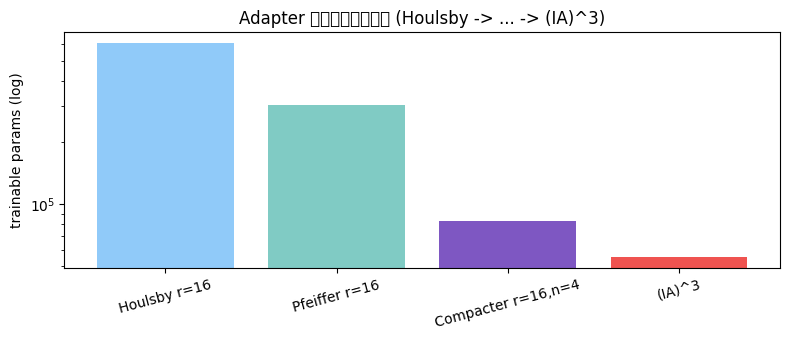

In [4]:
from houlsby_minimal import HoulsbyGPT2
from pfeiffer_minimal import PfeifferGPT2
from compacter_minimal import CompacterGPT2

torch.manual_seed(42)
data = [
    ('Houlsby r=16', sum(p.numel() for p in HoulsbyGPT2(r=16).parameters() if p.requires_grad)),
    ('Pfeiffer r=16', sum(p.numel() for p in PfeifferGPT2(r=16).parameters() if p.requires_grad)),
    ('Compacter r=16,n=4', sum(p.numel() for p in CompacterGPT2(r=16, n=4).parameters() if p.requires_grad)),
    ('(IA)^3', n_min),
]
for name, p in data:
    print(f'{name:<22} {p:>10,}')

names = [d[0] for d in data]
params = [d[1] for d in data]
plt.figure(figsize=(8, 3.5))
plt.bar(names, params, color=['#90caf9', '#80cbc4', '#7e57c2', '#ef5350'])
plt.yscale('log')
plt.ylabel('trainable params (log)')
plt.title('Adapter 家族参数压缩路径 (Houlsby -> ... -> (IA)^3)')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 4. (IA)³ mini training（需要更大 lr）

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


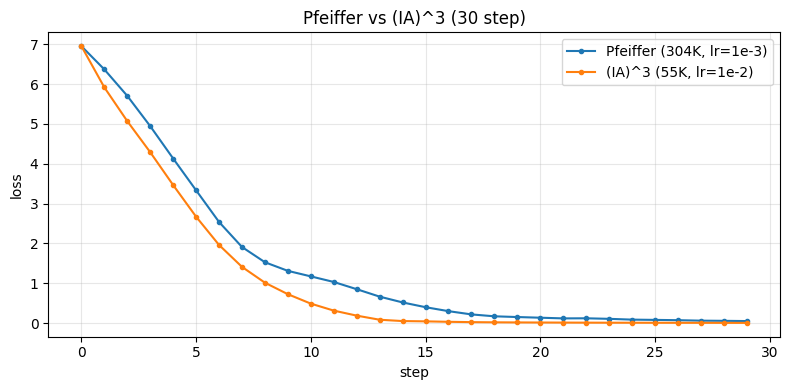

In [5]:
torch.manual_seed(42)
ia3 = IA3GPT2()
torch.manual_seed(42)
pfe = PfeifferGPT2(r=16)

tok = ia3.tokenizer
inputs = tok([
    'hello world this is a test', 'i love this product',
    'absolutely terrible movie', 'fantastic experience'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

models = [
    ('Pfeiffer (304K, lr=1e-3)', pfe, torch.optim.AdamW([p for p in pfe.parameters() if p.requires_grad], lr=1e-3)),
    ('(IA)^3 (55K, lr=1e-2)', ia3, torch.optim.AdamW([p for p in ia3.parameters() if p.requires_grad], lr=1e-2)),
]

losses = {n: [] for n, _, _ in models}
for step in range(30):
    for name, m, opt in models:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses[name].append(out.loss.item())

plt.figure(figsize=(8, 4))
for n in losses:
    plt.plot(losses[n], label=n, marker='o', markersize=3)
plt.xlabel('step'); plt.ylabel('loss')
plt.title('Pfeiffer vs (IA)^3 (30 step)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. 思考题

1. (IA)³ 用 lr=1e-2，而 Pfeiffer 用 lr=1e-3，为什么？（提示：参数初始化范围）
2. 训练后 `l_k` 的统计分布（mean, std）变化怎么样？
3. 把 `l_q`（query 缩放）也加进去会怎样？参数仅 +9K。

下节: **MAM Adapter** — 统一视角

本系列理论高峰，证明 Prefix Tuning ≡ Parallel Adapter ≡ 去非线性 LoRA。